### Imports

In [1]:
import json
import os
import pandas as pd

from utils_MS import *

# %load_ext autotime

/home/ealvarez/miniconda3/envs/graph_matching/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

import plotly.graph_objects as go
import sys
import torch
import torch.nn.functional as F
import os.path as osp

%matplotlib inline
from IPython import display
from IPython.display import HTML
from matplotlib import animation

from sklearn.cluster import HDBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split

from torch_geometric.datasets import KarateClub, Planetoid
from torch_geometric.data import Data
from torch import nn, optim, Tensor
from torch_geometric.utils import structured_negative_sampling, to_networkx
from torch_geometric.nn.conv.gcn_conv import gcn_norm
from torch_geometric.nn import LGConv, Node2Vec, GCNConv, GATv2Conv, SAGEConv
from torch_geometric.nn import global_mean_pool, global_add_pool
from torch.nn import Linear, Sequential, BatchNorm1d, ReLU, Dropout
from torch_geometric.nn import BatchNorm
import torch_geometric.transforms as T

from tqdm import tqdm

/home/ealvarez/miniconda3/envs/graph_matching/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, silhouette_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import (
	RandomForestClassifier,
	ExtraTreesClassifier,
	BaggingClassifier,
	AdaBoostClassifier,
	GradientBoostingClassifier,
	HistGradientBoostingClassifier
)

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import kneighbors_graph

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

In [7]:
def plot_class_distribution(labels, class_names=None):
	"""
	Plot the number of instances per class.

	Parameters
	----------
	labels : array-like
		List or array of class labels.
	class_names : dict or list, optional
		Mapping from class id to class name.
	"""
	labels = np.asarray(labels)

	# Count instances per class
	classes, counts = np.unique(labels, return_counts=True)

	# X-axis labels
	if class_names is None:
		x_labels = [str(c) for c in classes]
	elif isinstance(class_names, dict):
		x_labels = [class_names[c] for c in classes]
	else:
		x_labels = [class_names[c] for c in classes]

	# Plot
	fig, ax = plt.subplots(figsize=(8, 5))

	bars = ax.bar(
		x_labels,
		counts,
		color="steelblue",
		edgecolor="black"
	)

	# Display values on top of bars
	ax.bar_label(
		bars,
		fmt="%d",
		padding=3,
		fontsize=10,
		# fontweight="bold"
	)

	ax.set_xlabel("Class")
	ax.set_ylabel("Number of instances")
	ax.set_title("Class distribution")
	rotation=45

	ax.grid(axis="y", linestyle="--", alpha=0.5)
	plt.xticks(rotation=45)
	plt.tight_layout()
	plt.show()


In [8]:
# def run(params):

### Parameters

In [9]:
""" try:
	dir = os.path.dirname(os.path.abspath(__file__))
except:
	dir = os.getcwd()
print(dir) """

' try:\n\tdir = os.path.dirname(os.path.abspath(__file__))\nexcept:\n\tdir = os.getcwd()\nprint(dir) '

In [10]:
dict_dataset = {
	1: ["Mentos_2_process_NormalizationFiltered_format", ["Orange"]], # new mentos,  for Metabolomics
	2: ["deybis_filter_september_2br_3ar_format", ["SecoAmazonas"]],
	3: ["deybis_filter_december_2br_3ar_format", ["SecoAmazonas"]],
	4: ["deybis_filter_september_2br_10ar_format", ["SecoAmazonas"]],
	5: ["deybis_filter_december_2br_10ar_format", ["SecoAmazonas"]], # for Metabolomics
	6: ["deybis_filter_september_min_2br_3ar_format", ["SecoAmazonas"]],
	7: ["deybis_filter_december_min_2br_3ar_format", ["SecoAmazonas"]],
	8: ["vanessa_december_2br_3ar_format", ["SecoAmazonas"]],
	9: ["Pablo_2br_nar_format", ["AR"]],
	10: ["Pablo_2br_14ar_format", ["AR"]],
}
dataset = dict_dataset[9] # change
dataset

['Pablo_2br_nar_format', ['AR']]

In [11]:
params = {
	"exp": "exp0", # Change
	"methods": ["t-gae"], # ["vgae-base", "argva-base", "vgae-line", "dgi-tran", "t-gae"],
	"data_variations": ["none"],
	"has_transformation": True, # True or False
	"controls": dataset[1],
	"dimension": 64,
	"threshold_corr": 0.5,
	"threshold_log2": 0,
	"alpha": 0.05,
	"iterations": 1,
	"raw_data_file": dataset[0],
	"groups_id_no": ["Blank", "QC", "Std"],
	"sensitivity": False, # False: f1 (selectivity), True: f1 (selectivity), f2 (sensitivity)
	"obs": "",
	"seeds": [41, 42, 43, 44, 45, 46],
	
	"from": "python",
	"cuda": 0,
	"epochs": 100,
	"lr": 0.0001,
	"weight_decay": 1e-4,
	"patience": 10,
	"contamination": 0.1, # float in (0., 0.5)
	"n_jobs": 1, # -1 all
}

In [12]:
""" dir_path = "experiments/output"
res = sorted(os.listdir(dir_path))
n = len(res)
exp = "exp{}".format(n) """

exp = str(params["exp"])
exp

'exp0'

### Load dataset

In [13]:
exp = "exp30"
file = open("experiments/output/{}/parameters.json".format(exp))
params = json.load(file)

exp = params["exp"]

print("Exp:\t\t", exp)

methods = params["methods"]
print("Methods:\t", methods)

data_variations = params["data_variations"]
print("Data variations:", data_variations)

controls = params["controls"]
print("Control:\t", controls)

groups_id = params["groups_id"]
# groups_id = ['SecoAmazonas', 'SecoCusco', 'SecoSanMartin', 'FrescoAmazonas', 'FrescoCusco', 'FrescoSanMartin']
print("Groups id:\t", groups_id)

subgroups_id = params["subgroups_id"]
print("Subgroups id:\t", subgroups_id)

groups = params["groups"]
print("Groups:\t\t", groups)

# encoders = ["GIN", "GINE"]
encoders = ["GIN"]

Exp:		 exp30
Methods:	 ['t-gae']
Data variations: ['none']
Control:	 ['AR']
Groups id:	 ['AR', 'BC', 'BPH', 'CKD-Mild', 'CKD-Moderate', 'CKD-Severe', 'CKD5-HD', 'CKD5-PD', 'CRS', 'Health', 'LPRD', 'LSNB', 'OSA', 'PCa', 'PD', 'RCC', 'SGB', 'SKD']
Subgroups id:	 {'AR': ['1', '2'], 'BC': ['1', '2'], 'BPH': ['1', '2'], 'CKD-Mild': ['1', '2'], 'CKD-Moderate': ['1', '2'], 'CKD-Severe': ['1', '2'], 'CKD5-HD': ['1', '2'], 'CKD5-PD': ['1', '2'], 'CRS': ['1', '2'], 'Health': ['1', '2'], 'LPRD': ['1', '2'], 'LSNB': ['1', '2'], 'OSA': ['1', '2'], 'PCa': ['1', '2'], 'PD': ['1', '2'], 'RCC': ['1', '2'], 'SGB': ['1', '2'], 'SKD': ['1', '2']}
Groups:		 [['AR', 'BC'], ['AR', 'BPH'], ['AR', 'CKD-Mild'], ['AR', 'CKD-Moderate'], ['AR', 'CKD-Severe'], ['AR', 'CKD5-HD'], ['AR', 'CKD5-PD'], ['AR', 'CRS'], ['AR', 'Health'], ['AR', 'LPRD'], ['AR', 'LSNB'], ['AR', 'OSA'], ['AR', 'PCa'], ['AR', 'PD'], ['AR', 'RCC'], ['AR', 'SGB'], ['AR', 'SKD']]


In [14]:
params["raw_data_file"] = "Pablo_new_all" # Obs

In [15]:
# load dataset groups
if params["from"] == "python":
	df_raw = pd.read_csv("experiments/raw_data/{}.csv".format(params["raw_data_file"]), delimiter="|")
elif params["from"] == "drf":
	df_raw = pd.read_csv("{}".format(params["raw_data_file"]), delimiter="|") # from DRF
df_raw

,Alignment ID,Average Rt,Average Mz,Metabolite name,AR,AR.1,AR.2,AR.3,AR.4,AR.5,...,SKD.95,SKD.96,SKD.97,SKD.98,SKD.99,SKD.100,SKD.101,SKD.102,SKD.103,SKD.104
0,0,1.0,69.99951,Unknown,0.469752,-0.828568,-0.827568,0.200746,0.307196,0.509462,...,-0.729955,-0.248259,-0.270328,0.018966,0.016301,0.002993,-0.002321,-0.631255,0.037658,-0.167405
1,1,1.0,70.04025,Unknown,4.717494,2.647113,2.649208,2.651302,2.657570,2.659655,...,2.541524,2.410119,2.681824,1.790231,2.492337,2.168390,1.797099,3.568087,1.990979,2.795018
2,2,1.0,70.04151,Unknown,1.699017,1.924916,0.604168,1.560021,1.636312,1.426482,...,0.574928,0.988399,0.967726,1.214311,1.212080,1.200939,1.196488,0.657424,1.229950,1.057784
3,3,1.0,70.04908,Unknown,2.646457,0.766210,2.297061,2.267749,2.427032,2.043593,...,0.913754,1.323937,1.278797,1.735250,1.732453,1.718473,1.712885,1.024026,1.754852,1.540681
4,4,1.0,70.06267,Unknown,2.798181,1.189463,1.190252,1.191041,2.456294,1.192615,...,0.701041,1.192136,1.161074,1.434289,1.431611,1.418250,1.412920,0.794569,1.453092,1.248657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7352,7352,1.0,-754.83684,Unknown,2.565157,2.887150,2.889741,2.892329,2.900081,2.902660,...,2.766373,2.133379,2.041719,1.848851,2.084847,1.888788,2.581770,3.251662,2.124296,2.780038
7353,7353,1.0,-759.76498,Unknown,0.768066,1.122172,1.124789,1.127404,1.135235,1.137841,...,0.603652,1.857505,1.529659,1.616071,0.807890,0.804423,1.574497,0.640688,0.811359,0.768762
7354,7354,1.0,-766.05312,Unknown,1.875443,2.235337,2.238021,2.240702,2.248732,2.251404,...,1.249443,2.874881,2.645550,3.170971,1.308217,1.307299,2.970683,1.260471,1.818876,2.664618
7355,7355,1.0,-863.46939,Unknown,0.862675,1.114772,1.116666,1.118559,1.124228,1.126114,...,1.469004,0.784864,0.765867,0.667157,0.666257,0.424560,1.278780,1.277563,1.000997,1.076590


In [16]:
df_raw.columns = df_raw.columns.str.replace(r"\.\d+$", "", regex=True)
df_raw

,Alignment ID,Average Rt,Average Mz,Metabolite name,AR,AR,AR,AR,AR,AR,...,SKD,SKD,SKD,SKD,SKD,SKD,SKD,SKD,SKD,SKD
0,0,1.0,69.99951,Unknown,0.469752,-0.828568,-0.827568,0.200746,0.307196,0.509462,...,-0.729955,-0.248259,-0.270328,0.018966,0.016301,0.002993,-0.002321,-0.631255,0.037658,-0.167405
1,1,1.0,70.04025,Unknown,4.717494,2.647113,2.649208,2.651302,2.657570,2.659655,...,2.541524,2.410119,2.681824,1.790231,2.492337,2.168390,1.797099,3.568087,1.990979,2.795018
2,2,1.0,70.04151,Unknown,1.699017,1.924916,0.604168,1.560021,1.636312,1.426482,...,0.574928,0.988399,0.967726,1.214311,1.212080,1.200939,1.196488,0.657424,1.229950,1.057784
3,3,1.0,70.04908,Unknown,2.646457,0.766210,2.297061,2.267749,2.427032,2.043593,...,0.913754,1.323937,1.278797,1.735250,1.732453,1.718473,1.712885,1.024026,1.754852,1.540681
4,4,1.0,70.06267,Unknown,2.798181,1.189463,1.190252,1.191041,2.456294,1.192615,...,0.701041,1.192136,1.161074,1.434289,1.431611,1.418250,1.412920,0.794569,1.453092,1.248657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7352,7352,1.0,-754.83684,Unknown,2.565157,2.887150,2.889741,2.892329,2.900081,2.902660,...,2.766373,2.133379,2.041719,1.848851,2.084847,1.888788,2.581770,3.251662,2.124296,2.780038
7353,7353,1.0,-759.76498,Unknown,0.768066,1.122172,1.124789,1.127404,1.135235,1.137841,...,0.603652,1.857505,1.529659,1.616071,0.807890,0.804423,1.574497,0.640688,0.811359,0.768762
7354,7354,1.0,-766.05312,Unknown,1.875443,2.235337,2.238021,2.240702,2.248732,2.251404,...,1.249443,2.874881,2.645550,3.170971,1.308217,1.307299,2.970683,1.260471,1.818876,2.664618
7355,7355,1.0,-863.46939,Unknown,0.862675,1.114772,1.116666,1.118559,1.124228,1.126114,...,1.469004,0.784864,0.765867,0.667157,0.666257,0.424560,1.278780,1.277563,1.000997,1.076590


### Format dataset

In [17]:
# has transformation
""" columns_data = list(df_raw.columns)[4:]
if params["has_transformation"]:
	print("transformation")
	for column in columns_data:
		df_raw[column] = df_raw[column].apply(lambda x: 10**x)
df_raw """

' columns_data = list(df_raw.columns)[4:]\nif params["has_transformation"]:\n\tprint("transformation")\n\tfor column in columns_data:\n\t\tdf_raw[column] = df_raw[column].apply(lambda x: 10**x)\ndf_raw '

In [18]:
# concat
df_join_raw = pd.concat([
	df_raw.iloc[:, :]], axis=1)
df_join_raw.set_index("Alignment ID", inplace=True)
df_join_raw

,Average Rt,Average Mz,Metabolite name,AR,AR,AR,AR,AR,AR,AR,...,SKD,SKD,SKD,SKD,SKD,SKD,SKD,SKD,SKD,SKD
Alignment ID,,,,,,,,,,,,,,,,,,,,,
0,1.0,69.99951,Unknown,0.469752,-0.828568,-0.827568,0.200746,0.307196,0.509462,-0.825574,...,-0.729955,-0.248259,-0.270328,0.018966,0.016301,0.002993,-0.002321,-0.631255,0.037658,-0.167405
1,1.0,70.04025,Unknown,4.717494,2.647113,2.649208,2.651302,2.657570,2.659655,4.784085,...,2.541524,2.410119,2.681824,1.790231,2.492337,2.168390,1.797099,3.568087,1.990979,2.795018
2,1.0,70.04151,Unknown,1.699017,1.924916,0.604168,1.560021,1.636312,1.426482,1.514371,...,0.574928,0.988399,0.967726,1.214311,1.212080,1.200939,1.196488,0.657424,1.229950,1.057784
3,1.0,70.04908,Unknown,2.646457,0.766210,2.297061,2.267749,2.427032,2.043593,2.650094,...,0.913754,1.323937,1.278797,1.735250,1.732453,1.718473,1.712885,1.024026,1.754852,1.540681
4,1.0,70.06267,Unknown,2.798181,1.189463,1.190252,1.191041,2.456294,1.192615,2.864629,...,0.701041,1.192136,1.161074,1.434289,1.431611,1.418250,1.412920,0.794569,1.453092,1.248657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7352,1.0,-754.83684,Unknown,2.565157,2.887150,2.889741,2.892329,2.900081,2.902660,2.905237,...,2.766373,2.133379,2.041719,1.848851,2.084847,1.888788,2.581770,3.251662,2.124296,2.780038
7353,1.0,-759.76498,Unknown,0.768066,1.122172,1.124789,1.127404,1.135235,1.137841,1.140445,...,0.603652,1.857505,1.529659,1.616071,0.807890,0.804423,1.574497,0.640688,0.811359,0.768762
7354,1.0,-766.05312,Unknown,1.875443,2.235337,2.238021,2.240702,2.248732,2.251404,2.254074,...,1.249443,2.874881,2.645550,3.170971,1.308217,1.307299,2.970683,1.260471,1.818876,2.664618


In [19]:
# split
df_join_raw = df_join_raw.rename_axis(None)
# df_join_raw = df_join_raw.iloc[:, 2:]
df_join_raw

,Average Rt,Average Mz,Metabolite name,AR,AR,AR,AR,AR,AR,AR,...,SKD,SKD,SKD,SKD,SKD,SKD,SKD,SKD,SKD,SKD
0,1.0,69.99951,Unknown,0.469752,-0.828568,-0.827568,0.200746,0.307196,0.509462,-0.825574,...,-0.729955,-0.248259,-0.270328,0.018966,0.016301,0.002993,-0.002321,-0.631255,0.037658,-0.167405
1,1.0,70.04025,Unknown,4.717494,2.647113,2.649208,2.651302,2.657570,2.659655,4.784085,...,2.541524,2.410119,2.681824,1.790231,2.492337,2.168390,1.797099,3.568087,1.990979,2.795018
2,1.0,70.04151,Unknown,1.699017,1.924916,0.604168,1.560021,1.636312,1.426482,1.514371,...,0.574928,0.988399,0.967726,1.214311,1.212080,1.200939,1.196488,0.657424,1.229950,1.057784
3,1.0,70.04908,Unknown,2.646457,0.766210,2.297061,2.267749,2.427032,2.043593,2.650094,...,0.913754,1.323937,1.278797,1.735250,1.732453,1.718473,1.712885,1.024026,1.754852,1.540681
4,1.0,70.06267,Unknown,2.798181,1.189463,1.190252,1.191041,2.456294,1.192615,2.864629,...,0.701041,1.192136,1.161074,1.434289,1.431611,1.418250,1.412920,0.794569,1.453092,1.248657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7352,1.0,-754.83684,Unknown,2.565157,2.887150,2.889741,2.892329,2.900081,2.902660,2.905237,...,2.766373,2.133379,2.041719,1.848851,2.084847,1.888788,2.581770,3.251662,2.124296,2.780038
7353,1.0,-759.76498,Unknown,0.768066,1.122172,1.124789,1.127404,1.135235,1.137841,1.140445,...,0.603652,1.857505,1.529659,1.616071,0.807890,0.804423,1.574497,0.640688,0.811359,0.768762
7354,1.0,-766.05312,Unknown,1.875443,2.235337,2.238021,2.240702,2.248732,2.251404,2.254074,...,1.249443,2.874881,2.645550,3.170971,1.308217,1.307299,2.970683,1.260471,1.818876,2.664618
7355,1.0,-863.46939,Unknown,0.862675,1.114772,1.116666,1.118559,1.124228,1.126114,1.127999,...,1.469004,0.784864,0.765867,0.667157,0.666257,0.424560,1.278780,1.277563,1.000997,1.076590


In [20]:
# Filter node id (get common node id)
groups_id = ["AR", "Health", "CKD-Mild", "CKD-Severe", "LPRD"]

for encoder in encoders:
	for group_id in groups_id + ["union", "intersection"]:
		# Read common node
		# common_node_id = np.load(f"experiments/output/{exp}/common_nodes/{encoder}_{group_id}.npy")
		common_node_id = pd.read_csv(f"experiments/output/{exp}/common_nodes/{encoder}_{group_id}.csv", header=None)
		print(group_id, len(common_node_id)) #, common_node_id)

group_id = "LPRD" # "AR" # Change
common_node_id = pd.read_csv(f"experiments/output/{exp}/common_nodes/{encoder}_{group_id}.csv", header=None)
common_node_id

AR 589
Health 166
CKD-Mild 691
CKD-Severe 886
LPRD 159
union 2011
intersection 1


,0
0,34
1,48
2,111
3,128
4,167
...,...
154,5389
155,5390
156,5404
157,5405


In [21]:
common_node_id = common_node_id[0].to_numpy()
df_join_raw = df_join_raw.loc[common_node_id]
df_join_raw

,Average Rt,Average Mz,Metabolite name,AR,AR,AR,AR,AR,AR,AR,...,SKD,SKD,SKD,SKD,SKD,SKD,SKD,SKD,SKD,SKD
34,1.0,72.07209,Unknown,1.263833,1.520739,1.522987,1.525233,1.529719,1.531959,1.534197,...,1.039718,2.060080,1.119054,2.320050,1.208282,2.055094,1.202264,1.061398,2.464094,1.772413
48,1.0,74.09665,Unknown,4.063494,4.358631,3.876132,3.848099,3.808400,4.365123,4.332943,...,4.206667,4.339548,4.656519,5.535673,5.328049,3.729154,4.040930,4.379792,5.098033,4.139546
111,1.0,81.07001,Unknown,5.314724,6.735617,5.586111,5.867690,5.868954,5.890674,5.630594,...,6.066901,5.546356,6.485344,5.553212,6.161111,6.475371,6.259905,6.015324,5.742775,5.722301
128,1.0,83.07018,Unknown,-0.139036,-1.454339,-0.064382,-1.453334,-1.450327,-1.449328,-1.448330,...,-1.635313,-1.018294,-1.053811,-0.789612,-0.792675,-0.807960,-0.814057,-1.528654,-0.768101,-1.001894
167,1.0,86.06012,Unknown,5.351147,5.597616,5.600784,5.765368,5.794610,5.709605,5.930898,...,5.696768,5.497155,5.371579,4.882878,5.087810,4.748338,4.709234,5.941343,4.839319,6.209096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5389,1.0,540.15935,Unknown,3.197488,1.631262,3.138920,2.756681,3.123491,1.636990,3.466229,...,1.640304,3.611946,2.803228,2.929814,1.948907,1.940934,3.195751,1.672518,1.955270,1.868205
5390,1.0,550.21743,Unknown,4.774760,2.580827,3.325379,3.932426,3.766424,1.794465,3.290826,...,3.580790,3.075999,1.447197,3.447487,3.423710,1.584294,4.184592,2.368498,3.190807,4.090906
5404,1.0,582.87543,Unknown,1.829156,1.872202,2.897706,3.739055,4.206894,4.218497,4.545831,...,3.694220,1.221521,1.203547,3.114112,1.456054,1.448516,1.447007,3.475432,2.805333,1.383122
5405,1.0,589.89014,Unknown,-0.156308,-0.047175,1.906119,2.321682,2.276407,2.578503,2.618849,...,-0.429376,0.025142,-0.001632,0.143582,0.141039,0.128337,0.123264,-0.390879,0.161413,-0.029750


In [22]:
# get metadata
df_join_raw_metadata = df_join_raw.iloc[:, :2]
df_join_raw_metadata

,Average Rt,Average Mz
34,1.0,72.07209
48,1.0,74.09665
111,1.0,81.07001
128,1.0,83.07018
167,1.0,86.06012
...,...,...
5389,1.0,540.15935
5390,1.0,550.21743
5404,1.0,582.87543
5405,1.0,589.89014


In [23]:
df_join_raw_intensity = df_join_raw.iloc[:, 3:]
df_join_raw_intensity

,AR,AR,AR,AR,AR,AR,AR,AR,AR,AR,...,SKD,SKD,SKD,SKD,SKD,SKD,SKD,SKD,SKD,SKD
34,1.263833,1.520739,1.522987,1.525233,1.529719,1.531959,1.534197,2.717826,1.536433,2.709162,...,1.039718,2.060080,1.119054,2.320050,1.208282,2.055094,1.202264,1.061398,2.464094,1.772413
48,4.063494,4.358631,3.876132,3.848099,3.808400,4.365123,4.332943,4.367278,3.245110,3.984699,...,4.206667,4.339548,4.656519,5.535673,5.328049,3.729154,4.040930,4.379792,5.098033,4.139546
111,5.314724,6.735617,5.586111,5.867690,5.868954,5.890674,5.630594,6.185970,6.488986,5.755960,...,6.066901,5.546356,6.485344,5.553212,6.161111,6.475371,6.259905,6.015324,5.742775,5.722301
128,-0.139036,-1.454339,-0.064382,-1.453334,-1.450327,-1.449328,-1.448330,-1.447333,-1.446337,-1.445343,...,-1.635313,-1.018294,-1.053811,-0.789612,-0.792675,-0.807960,-0.814057,-1.528654,-0.768101,-1.001894
167,5.351147,5.597616,5.600784,5.765368,5.794610,5.709605,5.930898,5.751507,6.068194,5.742439,...,5.696768,5.497155,5.371579,4.882878,5.087810,4.748338,4.709234,5.941343,4.839319,6.209096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5389,3.197488,1.631262,3.138920,2.756681,3.123491,1.636990,3.466229,1.639841,1.642683,3.207937,...,1.640304,3.611946,2.803228,2.929814,1.948907,1.940934,3.195751,1.672518,1.955270,1.868205
5390,4.774760,2.580827,3.325379,3.932426,3.766424,1.794465,3.290826,3.546713,1.799211,2.766897,...,3.580790,3.075999,1.447197,3.447487,3.423710,1.584294,4.184592,2.368498,3.190807,4.090906
5404,1.829156,1.872202,2.897706,3.739055,4.206894,4.218497,4.545831,4.145860,3.375352,3.598508,...,3.694220,1.221521,1.203547,3.114112,1.456054,1.448516,1.447007,3.475432,2.805333,1.383122
5405,-0.156308,-0.047175,1.906119,2.321682,2.276407,2.578503,2.618849,2.501730,3.209184,-0.043629,...,-0.429376,0.025142,-0.001632,0.143582,0.141039,0.128337,0.123264,-0.390879,0.161413,-0.029750


In [24]:
# get 100 first AR
# df_join_raw_intensity = df_join_raw.iloc[:, 363:]
# df_join_raw_intensity

In [25]:
# get groups name
""" groups_id = []
for item in df_join_raw_intensity.columns.values:
	group_id = item.split("_")[0]
	groups_id.append(group_id) """

groups_id = df_join_raw_intensity.columns.values
print(groups_id)

['AR' 'AR' 'AR' ... 'SKD' 'SKD' 'SKD']


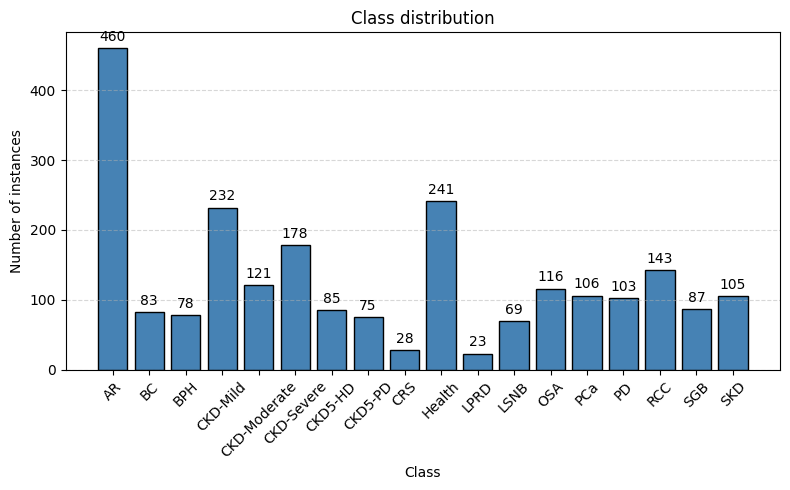

In [26]:

plot_class_distribution(groups_id)

In [27]:
# Remove JNU
""" df_join_raw_intensity = df_join_raw_intensity.loc[:, ~df_join_raw_intensity.columns.str.startswith("JNU")]
df_join_raw_intensity """

' df_join_raw_intensity = df_join_raw_intensity.loc[:, ~df_join_raw_intensity.columns.str.startswith("JNU")]\ndf_join_raw_intensity '

In [28]:
# get groups name
""" groups_id = []
for item in df_join_raw_intensity.columns.values:
	group_id = item.split("_")[0]
	groups_id.append(group_id)
print(groups_id) """

' groups_id = []\nfor item in df_join_raw_intensity.columns.values:\n\tgroup_id = item.split("_")[0]\n\tgroups_id.append(group_id)\nprint(groups_id) '

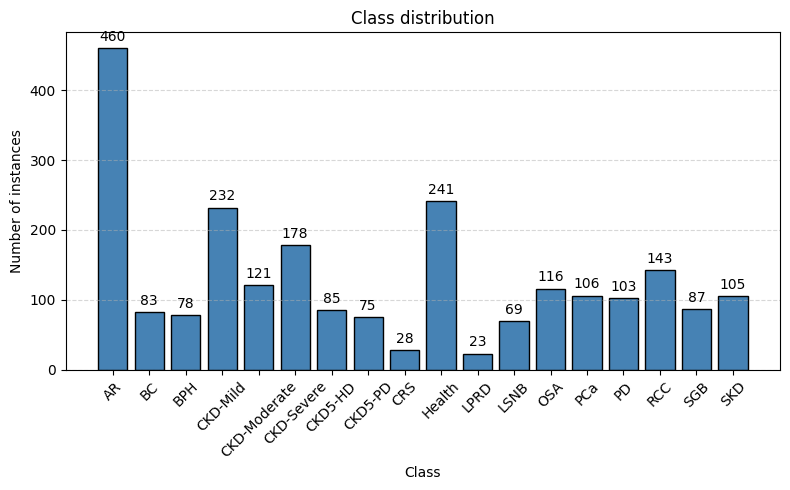

In [29]:
plot_class_distribution(groups_id)

### Classification

#### Data preparation

In [30]:
df_join_raw_intensity

,AR,AR,AR,AR,AR,AR,AR,AR,AR,AR,...,SKD,SKD,SKD,SKD,SKD,SKD,SKD,SKD,SKD,SKD
34,1.263833,1.520739,1.522987,1.525233,1.529719,1.531959,1.534197,2.717826,1.536433,2.709162,...,1.039718,2.060080,1.119054,2.320050,1.208282,2.055094,1.202264,1.061398,2.464094,1.772413
48,4.063494,4.358631,3.876132,3.848099,3.808400,4.365123,4.332943,4.367278,3.245110,3.984699,...,4.206667,4.339548,4.656519,5.535673,5.328049,3.729154,4.040930,4.379792,5.098033,4.139546
111,5.314724,6.735617,5.586111,5.867690,5.868954,5.890674,5.630594,6.185970,6.488986,5.755960,...,6.066901,5.546356,6.485344,5.553212,6.161111,6.475371,6.259905,6.015324,5.742775,5.722301
128,-0.139036,-1.454339,-0.064382,-1.453334,-1.450327,-1.449328,-1.448330,-1.447333,-1.446337,-1.445343,...,-1.635313,-1.018294,-1.053811,-0.789612,-0.792675,-0.807960,-0.814057,-1.528654,-0.768101,-1.001894
167,5.351147,5.597616,5.600784,5.765368,5.794610,5.709605,5.930898,5.751507,6.068194,5.742439,...,5.696768,5.497155,5.371579,4.882878,5.087810,4.748338,4.709234,5.941343,4.839319,6.209096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5389,3.197488,1.631262,3.138920,2.756681,3.123491,1.636990,3.466229,1.639841,1.642683,3.207937,...,1.640304,3.611946,2.803228,2.929814,1.948907,1.940934,3.195751,1.672518,1.955270,1.868205
5390,4.774760,2.580827,3.325379,3.932426,3.766424,1.794465,3.290826,3.546713,1.799211,2.766897,...,3.580790,3.075999,1.447197,3.447487,3.423710,1.584294,4.184592,2.368498,3.190807,4.090906
5404,1.829156,1.872202,2.897706,3.739055,4.206894,4.218497,4.545831,4.145860,3.375352,3.598508,...,3.694220,1.221521,1.203547,3.114112,1.456054,1.448516,1.447007,3.475432,2.805333,1.383122
5405,-0.156308,-0.047175,1.906119,2.321682,2.276407,2.578503,2.618849,2.501730,3.209184,-0.043629,...,-0.429376,0.025142,-0.001632,0.143582,0.141039,0.128337,0.123264,-0.390879,0.161413,-0.029750


In [31]:
df_join_raw_intensity_t = df_join_raw_intensity.T
df_join_raw_intensity_t

,34,48,111,128,167,178,238,246,258,371,...,5343,5355,5357,5381,5386,5389,5390,5404,5405,5420
AR,1.263833,4.063494,5.314724,-0.139036,5.351147,4.368443,4.088899,0.112566,2.614701,0.979862,...,1.296165,1.283056,3.238384,1.603982,4.638921,3.197488,4.774760,1.829156,-0.156308,1.936286
AR,1.520739,4.358631,6.735617,-1.454339,5.597616,3.940270,5.260974,0.553211,2.826301,1.146871,...,1.559171,1.485262,1.556869,0.116822,3.931004,1.631262,2.580827,1.872202,-0.047175,0.237618
AR,1.522987,3.876132,5.586111,-0.064382,5.600784,4.198340,4.230332,0.556830,2.827989,2.166558,...,1.562224,1.488102,3.770324,0.119079,4.597121,3.138920,3.325379,2.897706,1.906119,0.239757
AR,1.525233,3.848099,5.867690,-1.453334,5.765368,4.357427,4.232168,0.560446,2.829676,2.084902,...,3.830595,1.490939,4.003689,3.320822,4.637084,2.756681,3.932426,3.739055,2.321682,3.434401
AR,1.529719,3.808400,5.868954,-1.450327,5.794610,4.073287,4.234000,0.571272,2.834724,1.890393,...,4.615713,3.044893,4.675789,1.677017,4.680775,3.123491,3.766424,4.206894,2.276407,1.929782
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SKD,2.055094,3.729154,6.475371,-0.807960,4.748338,3.263082,4.938356,0.355662,2.705250,0.730085,...,1.090417,0.582830,3.717118,2.372572,3.690711,1.940934,1.584294,1.448516,0.128337,2.126702
SKD,1.202264,4.040930,6.259905,-0.814057,4.709234,3.736231,4.972151,0.351296,1.902059,2.431654,...,1.086603,0.579418,3.090391,0.282464,4.912098,3.195751,4.184592,1.447007,0.123264,0.335185
SKD,1.061398,4.379792,6.015324,-1.528654,5.941343,4.242425,4.756217,-0.022119,2.678448,0.559860,...,3.108402,3.039791,2.077722,1.448098,4.185819,1.672518,2.368498,3.475432,-0.390879,1.191007
SKD,2.464094,5.098033,5.742775,-0.768101,4.839319,3.965214,5.778758,0.381918,2.843441,3.170489,...,1.103746,0.598193,3.295681,2.978841,4.529047,1.955270,3.190807,2.805333,0.161413,2.722293


In [32]:
print(len(groups_id), groups_id)

2333 ['AR' 'AR' 'AR' ... 'SKD' 'SKD' 'SKD']


In [33]:
X = df_join_raw_intensity_t.values
X

array([[ 1.26383297,  4.06349424,  5.31472362, ...,  1.82915642,
        -0.15630797,  1.9362858 ],
       [ 1.52073915,  4.35863125,  6.73561708, ...,  1.8722017 ,
        -0.04717456,  0.23761801],
       [ 1.52298723,  3.87613203,  5.5861109 , ...,  2.89770605,
         1.90611935,  0.23975699],
       ...,
       [ 1.06139797,  4.37979165,  6.01532371, ...,  3.47543214,
        -0.3908786 ,  1.19100687],
       [ 2.46409365,  5.09803277,  5.7427747 , ...,  2.80533302,
         0.1614135 ,  2.72229264],
       [ 1.77241321,  4.13954611,  5.72230145, ...,  1.38312167,
        -0.02974953,  0.23861257]])

In [34]:
# Convertir a serie de categorías y obtener los códigos numéricos
encoder = LabelEncoder()
y = encoder.fit_transform(groups_id)
print(y)

y_classes = encoder.classes_
print(y_classes)

y_original = encoder.inverse_transform(y)
print(y_original.tolist())
print(groups_id)

[ 0  0  0 ... 17 17 17]
['AR' 'BC' 'BPH' 'CKD-Mild' 'CKD-Moderate' 'CKD-Severe' 'CKD5-HD'
 'CKD5-PD' 'CRS' 'Health' 'LPRD' 'LSNB' 'OSA' 'PCa' 'PD' 'RCC' 'SGB' 'SKD']
['AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR',

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y, random_state=42)
# print(y_test)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit only on train
X_test = scaler.transform(X_test)        # only transform on test

#### Model selection and train

In [36]:
param_dist = {
	"n_estimators": randint(100, 500),
	"max_depth": randint(3, 15),
	"min_samples_split": randint(2, 5, 10),
	"min_samples_leaf": randint(1, 5, 10)
}

# Create a random forest classifier
model = RandomForestClassifier(random_state=42, n_jobs=-1)

# Use random search to find the best hyperparameters
rand_search = RandomizedSearchCV(
	model, param_distributions=param_dist,
	n_iter=10, cv=5, scoring="accuracy",
	n_jobs=-1, random_state=42)

# Select and train model
search = rand_search.fit(X_train, y_train)

# Create a variable for the best model
best_model = rand_search.best_estimator_

# Print the best hyperparameters
print("Best hyperparameters:",  rand_search.best_params_)

Best hyperparameters: {'max_depth': 14, 'min_samples_leaf': 11, 'min_samples_split': 12, 'n_estimators': 158}


#### Evaluation

In [37]:
# Evaluation
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
recall_macro = recall_score(y_test, y_pred, average="macro")
f1_macro = f1_score(y_test, y_pred, average="macro")
classification_rep = classification_report(y_test, y_pred, output_dict=False)

print("Accuracy: ", accuracy)
print("Recall: ", recall_macro)
print("F1-score: ", f1_macro)

print(classification_rep)

Accuracy:  0.43683083511777304
Recall:  0.23996306099206854
F1-score:  0.22300710136695867
              precision    recall  f1-score   support

           0       0.53      0.97      0.68        92
           1       0.00      0.00      0.00        17
           2       0.00      0.00      0.00        16
           3       0.33      0.78      0.47        46
           4       0.17      0.04      0.07        24
           5       0.37      0.69      0.48        36
           6       0.67      0.24      0.35        17
           7       0.67      0.27      0.38        15
           8       0.00      0.00      0.00         6
           9       0.44      0.60      0.51        48
          10       0.00      0.00      0.00         4
          11       1.00      0.07      0.13        14
          12       1.00      0.04      0.08        23
          13       0.00      0.00      0.00        21
          14       0.27      0.19      0.22        21
          15       0.42      0.17      0.24 

/home/ealvarez/miniconda3/envs/graph_matching/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ealvarez/miniconda3/envs/graph_matching/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ealvarez/miniconda3/envs/graph_matching/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

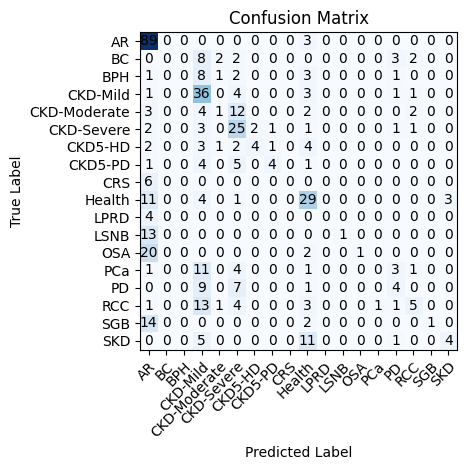

In [38]:
cm = confusion_matrix(y_test, y_pred)
class_names = y_classes # best_model.classes_
tick_marks = np.arange(len(class_names))

plt.figure()
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
# plt.colorbar()
plt.xticks(tick_marks, class_names, rotation=45, ha="right", rotation_mode="anchor")
plt.yticks(tick_marks, class_names)

# Values inside each cell
for i in range(cm.shape[0]):
	for j in range(cm.shape[1]):
		plt.text(
			j, i,
			format(cm[i, j], "d"),
			ha="center",
			va="center"
		)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

### Node classification

In [39]:
def visualize_(h, color):
	z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

	plt.figure(figsize=(10,10))
	plt.xticks([])
	plt.yticks([])

	plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
	plt.show()

def visualize(h, color, class_names):
	z = TSNE(n_components=2, random_state=42).fit_transform(
		h.detach().cpu().numpy()
	)

	color = np.asarray(color)
	class_names = np.asarray(class_names)

	plt.figure(figsize=(10, 10))

	scatter = plt.scatter(
		z[:, 0],
		z[:, 1],
		c=color,
		cmap="tab20",
		s=70,
		alpha=0.8,
	)

	plt.xticks([])
	plt.yticks([])

	# Obtener una etiqueta por clase
	# unique_classes = np.unique(color)
	# handles = scatter.legend_elements()[0]
	unique_classes = np.unique(color)
	handles = scatter.legend_elements(num=list(unique_classes))[0]

	labels = [
		class_names[color == c][0]
		for c in unique_classes
	]

	plt.legend(
		handles,
		labels,
		title="Node types",
		loc="best"
	)

	plt.tight_layout()
	plt.show()
	
# Calculate accuracy
def accuracy(pred_y, y):
	return (pred_y == y).sum() / len(y)

In [40]:
import torch

torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

#### Preprocessing

##### Option 1 (partial correlations)

In [ ]:
# Partial correlation

""" df_matrix = pg.pcorr(df_join_raw_intensity)
df_matrix """


from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf
scaler = StandardScaler()

df_subgroup_scaled = scaler.fit_transform(df_join_raw_intensity)
lw = LedoitWolf()
lw.fit(df_subgroup_scaled)

# Matriz de covarianza regularizada
cov = lw.covariance_
std = np.sqrt(np.diag(cov))
corr = cov / np.outer(std, std)
df_matrix = pd.DataFrame(corr)
df_matrix

In [ ]:
# Edge list

threshold = np.percentile(np.abs(df_matrix), 95) # Important

df_weighted_edges = (df_matrix.where(np.triu(np.ones(df_matrix.shape), k=1).astype(bool)).stack())
df_weighted_edges = df_weighted_edges.dropna().to_frame()
df_weighted_edges.reset_index(inplace=True)
df_weighted_edges.columns = ["source", "target", "weight"]
df_weighted_edges = df_weighted_edges[df_weighted_edges["weight"].abs() >= threshold]
df_weighted_edges


In [ ]:
num_nodes = pd.concat([df_weighted_edges["source"], df_weighted_edges["target"]]).nunique()
num_nodes

##### Option 2 (K-NN)

In [41]:
df_join_raw_intensity

,AR,AR,AR,AR,AR,AR,AR,AR,AR,AR,...,SKD,SKD,SKD,SKD,SKD,SKD,SKD,SKD,SKD,SKD
34,1.263833,1.520739,1.522987,1.525233,1.529719,1.531959,1.534197,2.717826,1.536433,2.709162,...,1.039718,2.060080,1.119054,2.320050,1.208282,2.055094,1.202264,1.061398,2.464094,1.772413
48,4.063494,4.358631,3.876132,3.848099,3.808400,4.365123,4.332943,4.367278,3.245110,3.984699,...,4.206667,4.339548,4.656519,5.535673,5.328049,3.729154,4.040930,4.379792,5.098033,4.139546
111,5.314724,6.735617,5.586111,5.867690,5.868954,5.890674,5.630594,6.185970,6.488986,5.755960,...,6.066901,5.546356,6.485344,5.553212,6.161111,6.475371,6.259905,6.015324,5.742775,5.722301
128,-0.139036,-1.454339,-0.064382,-1.453334,-1.450327,-1.449328,-1.448330,-1.447333,-1.446337,-1.445343,...,-1.635313,-1.018294,-1.053811,-0.789612,-0.792675,-0.807960,-0.814057,-1.528654,-0.768101,-1.001894
167,5.351147,5.597616,5.600784,5.765368,5.794610,5.709605,5.930898,5.751507,6.068194,5.742439,...,5.696768,5.497155,5.371579,4.882878,5.087810,4.748338,4.709234,5.941343,4.839319,6.209096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5389,3.197488,1.631262,3.138920,2.756681,3.123491,1.636990,3.466229,1.639841,1.642683,3.207937,...,1.640304,3.611946,2.803228,2.929814,1.948907,1.940934,3.195751,1.672518,1.955270,1.868205
5390,4.774760,2.580827,3.325379,3.932426,3.766424,1.794465,3.290826,3.546713,1.799211,2.766897,...,3.580790,3.075999,1.447197,3.447487,3.423710,1.584294,4.184592,2.368498,3.190807,4.090906
5404,1.829156,1.872202,2.897706,3.739055,4.206894,4.218497,4.545831,4.145860,3.375352,3.598508,...,3.694220,1.221521,1.203547,3.114112,1.456054,1.448516,1.447007,3.475432,2.805333,1.383122
5405,-0.156308,-0.047175,1.906119,2.321682,2.276407,2.578503,2.618849,2.501730,3.209184,-0.043629,...,-0.429376,0.025142,-0.001632,0.143582,0.141039,0.128337,0.123264,-0.390879,0.161413,-0.029750


In [42]:
df_join_raw_intensity_t = df_join_raw_intensity.T
df_join_raw_intensity_t

,34,48,111,128,167,178,238,246,258,371,...,5343,5355,5357,5381,5386,5389,5390,5404,5405,5420
AR,1.263833,4.063494,5.314724,-0.139036,5.351147,4.368443,4.088899,0.112566,2.614701,0.979862,...,1.296165,1.283056,3.238384,1.603982,4.638921,3.197488,4.774760,1.829156,-0.156308,1.936286
AR,1.520739,4.358631,6.735617,-1.454339,5.597616,3.940270,5.260974,0.553211,2.826301,1.146871,...,1.559171,1.485262,1.556869,0.116822,3.931004,1.631262,2.580827,1.872202,-0.047175,0.237618
AR,1.522987,3.876132,5.586111,-0.064382,5.600784,4.198340,4.230332,0.556830,2.827989,2.166558,...,1.562224,1.488102,3.770324,0.119079,4.597121,3.138920,3.325379,2.897706,1.906119,0.239757
AR,1.525233,3.848099,5.867690,-1.453334,5.765368,4.357427,4.232168,0.560446,2.829676,2.084902,...,3.830595,1.490939,4.003689,3.320822,4.637084,2.756681,3.932426,3.739055,2.321682,3.434401
AR,1.529719,3.808400,5.868954,-1.450327,5.794610,4.073287,4.234000,0.571272,2.834724,1.890393,...,4.615713,3.044893,4.675789,1.677017,4.680775,3.123491,3.766424,4.206894,2.276407,1.929782
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SKD,2.055094,3.729154,6.475371,-0.807960,4.748338,3.263082,4.938356,0.355662,2.705250,0.730085,...,1.090417,0.582830,3.717118,2.372572,3.690711,1.940934,1.584294,1.448516,0.128337,2.126702
SKD,1.202264,4.040930,6.259905,-0.814057,4.709234,3.736231,4.972151,0.351296,1.902059,2.431654,...,1.086603,0.579418,3.090391,0.282464,4.912098,3.195751,4.184592,1.447007,0.123264,0.335185
SKD,1.061398,4.379792,6.015324,-1.528654,5.941343,4.242425,4.756217,-0.022119,2.678448,0.559860,...,3.108402,3.039791,2.077722,1.448098,4.185819,1.672518,2.368498,3.475432,-0.390879,1.191007
SKD,2.464094,5.098033,5.742775,-0.768101,4.839319,3.965214,5.778758,0.381918,2.843441,3.170489,...,1.103746,0.598193,3.295681,2.978841,4.529047,1.955270,3.190807,2.805333,0.161413,2.722293


In [43]:
X = df_join_raw_intensity_t.values
X

array([[ 1.26383297,  4.06349424,  5.31472362, ...,  1.82915642,
        -0.15630797,  1.9362858 ],
       [ 1.52073915,  4.35863125,  6.73561708, ...,  1.8722017 ,
        -0.04717456,  0.23761801],
       [ 1.52298723,  3.87613203,  5.5861109 , ...,  2.89770605,
         1.90611935,  0.23975699],
       ...,
       [ 1.06139797,  4.37979165,  6.01532371, ...,  3.47543214,
        -0.3908786 ,  1.19100687],
       [ 2.46409365,  5.09803277,  5.7427747 , ...,  2.80533302,
         0.1614135 ,  2.72229264],
       [ 1.77241321,  4.13954611,  5.72230145, ...,  1.38312167,
        -0.02974953,  0.23861257]])

In [44]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_join_raw_intensity_t.values)
X_scaled

array([[-0.59210553, -0.84763145, -1.03702176, ..., -0.65170529,
        -0.69933903,  1.21768419],
       [-0.14297888, -0.37330687,  2.09559443, ..., -0.60901445,
        -0.60826202, -0.59976609],
       [-0.13904875, -1.14874754, -0.4386995 , ...,  0.40804568,
         1.02185435, -0.59747754],
       ...,
       [-0.94600496, -0.3392993 ,  0.50757763, ...,  0.98101465,
        -0.89509934,  0.42029025],
       [ 1.50620541,  0.81501006, -0.09330586, ...,  0.31643326,
        -0.4341854 ,  2.05865401],
       [ 0.2970009 , -0.72540594, -0.13844285, ..., -1.0940673 ,
        -0.59372001, -0.59870198]])

In [45]:
# similarity = cosine_similarity(X_scaled)
# similarity

In [46]:
# Similarity matrix

k = 20 # Change

A = kneighbors_graph(
	X_scaled, # X, X_scaled
	n_neighbors=k,
	metric="euclidean", # cosine, 
	mode="distance",
	include_self=False
)
A.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [47]:
# Edge list

edges = []

n = A.shape[0]

for i in range(n):
	for j in range(i + 1, n): # Solo parte superior (grafo no dirigido)
		if A[i, j] != 0:
			edges.append((i, j, A[i, j]))

print(edges)

df_weighted_edges = pd.DataFrame(edges, columns=["source", "target", "weight"])
df_weighted_edges

[(0, 122, 8.946384370916682), (0, 123, 10.123940226328026), (0, 124, 8.377052202436312), (0, 141, 9.741753518575273), (0, 157, 11.186104317006237), (0, 158, 10.627069152512055), (0, 159, 10.490566980521272), (0, 165, 9.27284187290916), (0, 167, 8.544278318398307), (0, 214, 11.024248984249285), (0, 417, 11.160847362362015), (0, 425, 11.148686127544787), (0, 1494, 11.17346719471025), (0, 1726, 9.486989974980343), (0, 1773, 11.063095872160904), (0, 2141, 11.348062032605277), (0, 2158, 10.666182846642636), (0, 2164, 10.613127362833003), (0, 2165, 10.198552431652425), (0, 2166, 9.193296735273139), (1, 33, 11.981681076622973), (1, 133, 12.223266677942712), (1, 146, 12.199484432060656), (1, 184, 12.2240725974889), (1, 197, 10.354681426134082), (1, 198, 9.839252529143117), (1, 210, 11.03678774552232), (1, 348, 10.936128674474217), (1, 372, 12.13635996388264), (1, 448, 12.026881928367876), (1, 457, 11.926707597752927), (1, 1527, 10.873404233161216), (1, 1531, 10.957045162608303), (1, 1591, 11.8

,source,target,weight
0,0,122,8.946384
1,0,123,10.123940
2,0,124,8.377052
3,0,141,9.741754
4,0,157,11.186104
...,...,...,...
22223,2322,2327,13.268173
22224,2322,2328,15.020812
22225,2322,2329,14.684374
22226,2327,2328,12.477237


#### Data preparation

In [48]:
df_weighted_edges

,source,target,weight
0,0,122,8.946384
1,0,123,10.123940
2,0,124,8.377052
3,0,141,9.741754
4,0,157,11.186104
...,...,...,...
22223,2322,2327,13.268173
22224,2322,2328,15.020812
22225,2322,2329,14.684374
22226,2327,2328,12.477237


In [49]:
# x = torch.tensor(X_scaled, dtype=torch.float)
# x.dtype, x.shape

In [50]:
# x = torch.eye(num_nodes, dtype=torch.float)
# x.dtype, x.shape

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y, random_state=42)

In [52]:
edge_index = torch.tensor(df_weighted_edges.iloc[:, [0, 1]].values, dtype=torch.long)
x = torch.tensor(X_scaled, dtype=torch.float)

data = Data(x=x, edge_index=edge_index.t().contiguous())

num_nodes = data.num_nodes
# x = torch.eye(num_nodes, dtype=torch.float)
# data.x = x

y_ = torch.tensor(y, dtype=torch.long)
data.y = y_

# 2. Obtener los índices de todos los nodos en formato numpy
node_indices = torch.arange(num_nodes).numpy()
labels = data.y.numpy()

# 3. Dividir los índices usando sklearn (80% entrenamiento, 20% prueba)
# Puedes usar "stratify=labels" si quieres mantener la proporción de clases
train_idx, test_idx = train_test_split(node_indices, test_size=0.2, shuffle=True, stratify=labels, random_state=42)

# 4. Crear las máscaras booleanas vacías (en falso)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

# 5. Cambiar a True las posiciones correspondientes a cada conjunto
train_mask[train_idx] = True
test_mask[test_idx] = True

# 6. Asignar las máscaras al objeto Data de PyTorch Geometric
data.train_mask = train_mask
data.test_mask = test_mask
data

Data(x=[2333, 159], edge_index=[2, 22228], y=[2333], train_mask=[2333], test_mask=[2333])

In [53]:
print(data)
print()

# Gather some statistics about the graph.
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Average node degree: {data.num_edges / data.num_nodes:.2f}")
print(f"Number of training nodes: {data.train_mask.sum()}")
print(f"Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}")
print(f"Contains isolated nodes: {data.has_isolated_nodes()}")
print(f"Contains self-loops: {data.has_self_loops()}")
print(f"Is undirected: {data.is_undirected()}")

Data(x=[2333, 159], edge_index=[2, 22228], y=[2333], train_mask=[2333], test_mask=[2333])

Number of nodes: 2333
Number of edges: 22228
Average node degree: 9.53
Number of training nodes: 1866
Training node label rate: 0.80
Contains isolated nodes: True
Contains self-loops: False
Is undirected: False


In [54]:
transform = T.Compose([T.ToUndirected()])#, T.AddSelfLoops()])
data = transform(data) 

print(data)
print()

# Gather some statistics about the graph.
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Average node degree: {data.num_edges / data.num_nodes:.2f}")
print(f"Number of training nodes: {data.train_mask.sum()}")
print(f"Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}")
print(f"Contains isolated nodes: {data.has_isolated_nodes()}")
print(f"Contains self-loops: {data.has_self_loops()}")
print(f"Is undirected: {data.is_undirected()}")

Data(x=[2333, 159], edge_index=[2, 44456], y=[2333], train_mask=[2333], test_mask=[2333])

Number of nodes: 2333
Number of edges: 44456
Average node degree: 19.06
Number of training nodes: 1866
Training node label rate: 0.80
Contains isolated nodes: True
Contains self-loops: False
Is undirected: True


In [55]:
data.x.shape, data.x.size(-1), data.num_features

(torch.Size([2333, 159]), 159, 159)

In [56]:
data.x

tensor([[-0.5921, -0.8476, -1.0370,  ..., -0.6517, -0.6993,  1.2177],
        [-0.1430, -0.3733,  2.0956,  ..., -0.6090, -0.6083, -0.5998],
        [-0.1390, -1.1487, -0.4387,  ...,  0.4080,  1.0219, -0.5975],
        ...,
        [-0.9460, -0.3393,  0.5076,  ...,  0.9810, -0.8951,  0.4203],
        [ 1.5062,  0.8150, -0.0933,  ...,  0.3164, -0.4342,  2.0587],
        [ 0.2970, -0.7254, -0.1384,  ..., -1.0941, -0.5937, -0.5987]])

In [57]:
num_features = data.num_features # data.x.size(-1)

# 2. Obtener el número de clases (valores únicos en el tensor y)
if data.y.dim() <= 1:
	# Para clasificación de nodos o grafos con etiquetas discretas
	num_classes = int(data.y.max()) + 1
else:
	# Para etiquetas representadas en formato one-hot o multi-label
	num_classes = data.y.size(-1)

print(f"Number of features: {num_features}")
print(f"Number of classes: {num_classes}")

Number of features: 159
Number of classes: 18


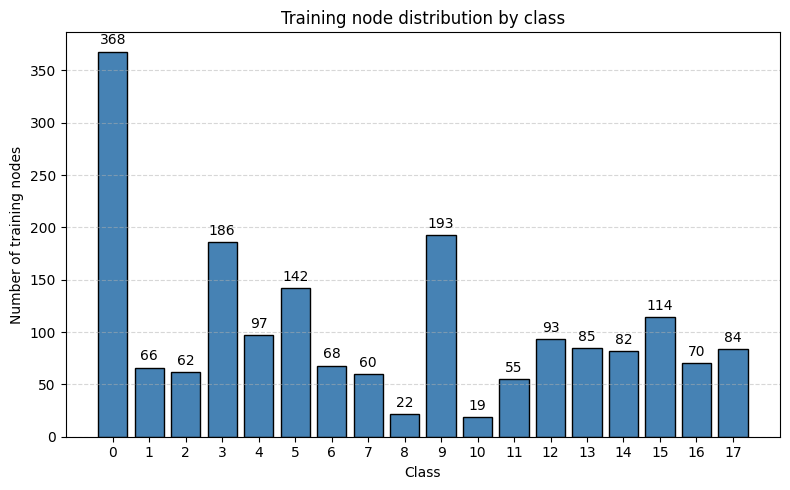

In [58]:
# Número de nodos por clase en el conjunto de entrenamiento
unique, counts = torch.unique(
	data.y[data.train_mask],
	return_counts=True
)

classes = unique.cpu().numpy()
counts = counts.cpu().numpy()

plt.figure(figsize=(8, 5))

bars = plt.bar(
	classes.astype(str),
	counts,
	color="steelblue",
	edgecolor="black"
)

# Mostrar el número de nodos sobre cada barra
plt.bar_label(
	bars,
	fmt="%d",
	padding=3,
	fontsize=10,
	# fontweight="bold"
)

plt.xlabel("Class")
plt.ylabel("Number of training nodes")
plt.title("Training node distribution by class")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

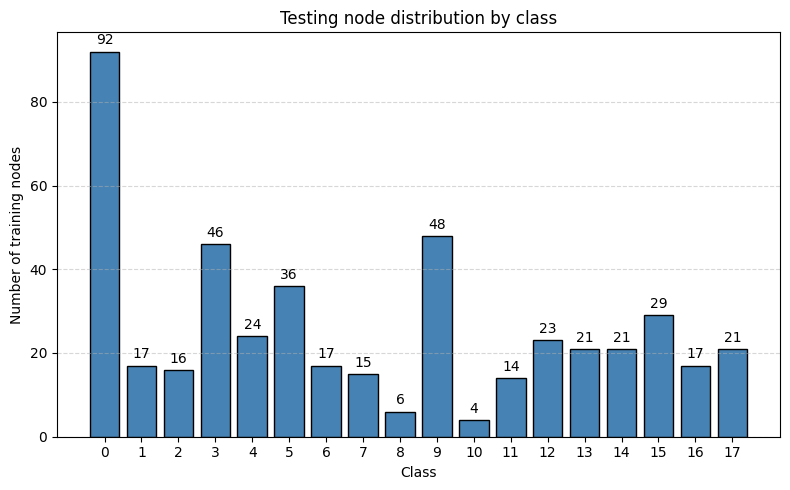

In [59]:
# Número de nodos por clase en el conjunto de entrenamiento
unique, counts = torch.unique(
	data.y[data.test_mask],
	return_counts=True
)

classes = unique.cpu().numpy()
counts = counts.cpu().numpy()

plt.figure(figsize=(8, 5))

bars = plt.bar(
	classes.astype(str),
	counts,
	color="steelblue",
	edgecolor="black"
)

# Mostrar el número de nodos sobre cada barra
plt.bar_label(
	bars,
	fmt="%d",
	padding=3,
	fontsize=10,
	# fontweight="bold"
)

plt.xlabel("Class")
plt.ylabel("Number of training nodes")
plt.title("Testing node distribution by class")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#### GCN

In [60]:
# Define GCN

class GCN_(torch.nn.Module):
	def __init__(self, num_features, dim_h, num_classes):
		super(GCN, self).__init__()
		torch.manual_seed(42)
		self.conv1 = GCNConv(num_features, 1024)
		self.conv2 = GCNConv(1024, 512)
		self.conv3 = GCNConv(512, 128)
		# self.conv2 = GCNConv(1024, dim_h)
		self.classifier = Linear(dim_h, num_classes)

	def forward(self, x, edge_index):
		# Node embeddings
		h = self.conv1(x, edge_index)
		h = h.relu()
		h = self.conv2(h, edge_index)
		h = h.relu()
		# h = self.conv3(h, edge_index)
		# h = h.relu()
		h = F.dropout(h, p=0.5, training=self.training)
		h = self.conv3(h, edge_index)
		z = h.relu()  # final GNN embedding space

		# Prediction head: linear classifier
		out = self.classifier(z)

		return out, z

class GCN(torch.nn.Module):
	def __init__(self, num_features, dim_h, num_classes, p_dropout=0.5):
		super().__init__()
		torch.manual_seed(42)

		self.dropout_in = Dropout(p_dropout)
		self.conv1 = GCNConv(num_features, 1024, cached=True)
		self.bn1 = BatchNorm(1024)
		self.conv2 = GCNConv(1024, dim_h, cached=True)
		self.bn2 = BatchNorm(dim_h)
		# proyección lineal para que la conexión residual calce en dimensión
		# (1024 -> dim_h), solo se usa si dim_h != 1024
		self.proyeccion_residual = (
			Linear(1024, dim_h) if dim_h != 1024 else torch.nn.Identity()
		)
		self.dropout_mid = Dropout(p_dropout)
		self.classifier = Linear(dim_h, num_classes)

	def forward(self, x, edge_index):
		x = self.dropout_in(x)
		h = self.conv1(x, edge_index)
		h = self.bn1(h)
		h = h.relu()
		h = self.dropout_mid(h)
		h2 = self.conv2(h, edge_index)
		h2 = self.bn2(h2)

		# conexión residual: mezcla la representación de conv1 (proyectada)
		# con la de conv2, para no perder del todo la señal "local" de la
		# primera capa cuando el grafo agrega mucho ruido de vecinos lejanos.
		z = h2 + self.proyeccion_residual(h)   # <- embedding final, SIN relu

		out = self.classifier(z.relu())         # la no-linealidad va aquí,
												# dentro del head, no en z
		return out, z


# Hyperparameters
dimension = 128 # dimension of node embeddings
number_features = num_features # dimension of node features
number_classes = num_classes # number of classes

model = GCN(num_features=number_features, dim_h=dimension, num_classes=number_classes)
print(model)

GCN(
  (dropout_in): Dropout(p=0.5, inplace=False)
  (conv1): GCNConv(159, 1024)
  (bn1): BatchNorm(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): GCNConv(1024, 128)
  (bn2): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (proyeccion_residual): Linear(in_features=1024, out_features=128, bias=True)
  (dropout_mid): Dropout(p=0.5, inplace=False)
  (classifier): Linear(in_features=128, out_features=18, bias=True)
)


In [61]:
np.unique(groups_id)

array(['AR', 'BC', 'BPH', 'CKD-Mild', 'CKD-Moderate', 'CKD-Severe',
       'CKD5-HD', 'CKD5-PD', 'CRS', 'Health', 'LPRD', 'LSNB', 'OSA',
       'PCa', 'PD', 'RCC', 'SGB', 'SKD'], dtype=object)

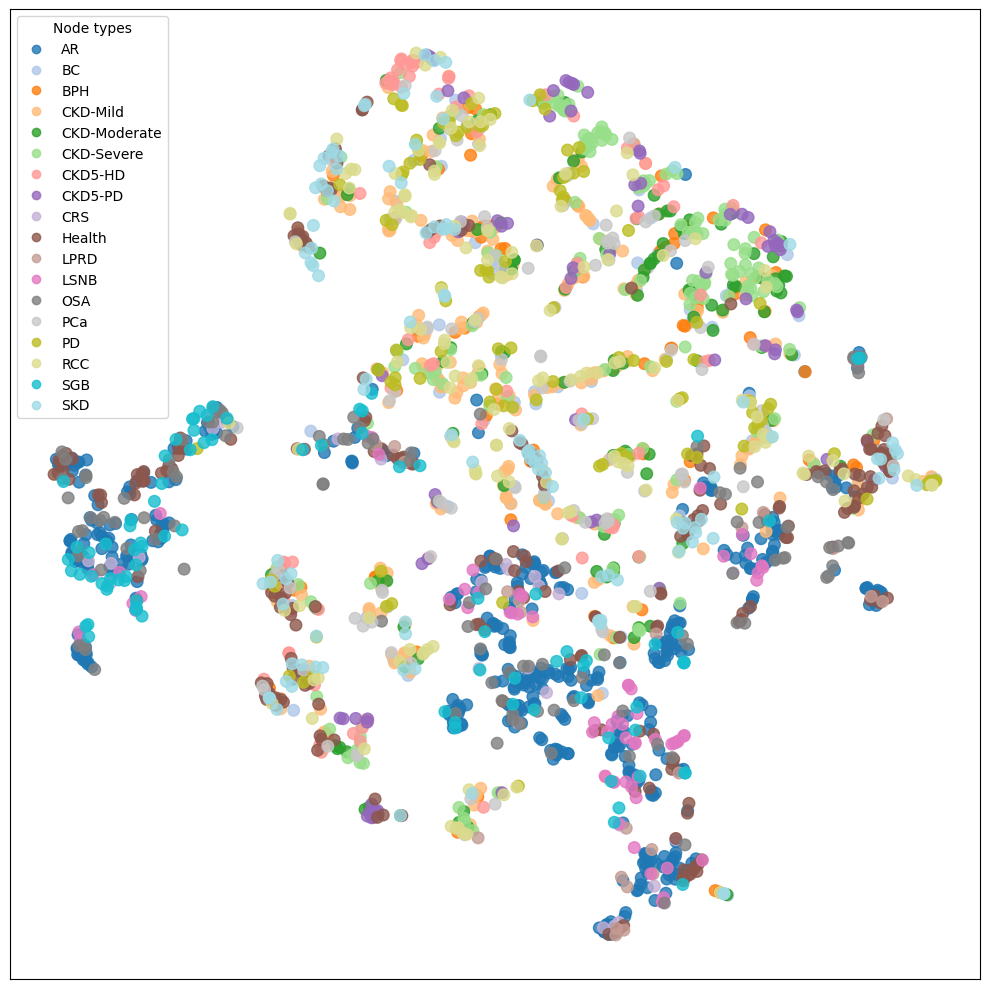

In [62]:
# Vizualization
model.eval()
out, z = model(data.x, data.edge_index)

visualize(z, data.y, y_original)

In [63]:
# Train

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)#, weight_decay=5e-4)

# Data for animations
embeddings = []
losses = []
accuracies = []
outputs = []
epochs = 1000

# Early stopping: parameters
patience = 30              # epochs without improvement before stopping
min_delta = 1e-4           # minimum val_loss improvement to count as "improvement"
best_val_loss = float("inf")
epochs_without_improvement = 0
best_weights = None

# Training loop
pbar = tqdm(range(1, epochs + 1))
for epoch in pbar:
	# Mode train
	model.train()
	
	# Clear gradients
	optimizer.zero_grad()

	# Forward pass
	out, z = model(data.x, data.edge_index)

	# Calculate loss function
	# loss = criterion(out, data.y)
	loss = criterion(out[data.train_mask], data.y[data.train_mask])

	# Calculate accuracy
	acc = accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])

	# Compute gradients
	loss.backward()

	# Tune parameters
	optimizer.step()

	# Validation (no gradients, no dropout)
	model.eval()
	with torch.no_grad():
		out_val, _ = model(data.x, data.edge_index)
		val_loss = criterion(out_val[data.test_mask], data.y[data.test_mask])

	# Store data for animations
	embeddings.append(z)
	losses.append(loss.item())
	accuracies.append(acc)
	outputs.append(out.argmax(dim=1))

	# Print metrics
	pbar.set_description(
        f"Epoch {epoch:>3} | Loss: {loss:.2f} | Acc: {acc*100:.2f}% | Val Loss: {val_loss:.3f}"
    )
	# pbar.set_description(f"Epoch {epoch:>3} | Loss: {loss:.2f} | Acc: {acc*100:.2f}%")

	# Print metrics every 10 epochs
	""" if epoch % 10 == 0:
		print(f"Epoch {epoch:>3} | Loss: {loss:.2f} | Acc: {acc*100:.2f}%") """

	# Early stopping
	""" if val_loss < best_val_loss - min_delta:
		best_val_loss = val_loss
		epochs_without_improvement = 0
		# best_weights = copy.deepcopy(model.state_dict())   # checkpoint of the best model so far
	else:
		epochs_without_improvement += 1
		if epochs_without_improvement >= patience:
			print(f"\nEarly stopping at epoch {epoch} "
				f"(no val_loss improvement for {patience} epochs). "
				f"Best val_loss: {best_val_loss:.3f}")
			break """

# Restore the weights from the best epoch (not necessarily the last one)
""" if best_weights is not None:
    model.load_state_dict(best_weights)
    print("Weights restored to the best checkpoint (based on val_loss).") """

Epoch 1000 | Loss: 0.16 | Acc: 94.86% | Val Loss: 2.927: 100%|██████████| 1000/1000 [02:50<00:00,  5.87it/s]


' if best_weights is not None:\n    model.load_state_dict(best_weights)\n    print("Weights restored to the best checkpoint (based on val_loss).") '

In [64]:
# Model evaluation
""" model.eval()
out, z = model(data.x, data.edge_index)
acc = accuracy(out[data.test_mask].argmax(dim=1), data.y[data.test_mask])
print(f"Acc: {acc*100:.2f}%") """

' model.eval()\nout, z = model(data.x, data.edge_index)\nacc = accuracy(out[data.test_mask].argmax(dim=1), data.y[data.test_mask])\nprint(f"Acc: {acc*100:.2f}%") '

In [65]:
# Evaluation
model.eval()
with torch.no_grad():
	# 2. Obtener las predicciones del modelo (log_softmax o logits)
	out, z = model(data.x, data.edge_index)
	
	# 3. Convertir las salidas en las clases predichas (índice con mayor valor)
	y_pred = out.argmax(dim=1)

# 4. Filtrar solo los nodos del conjunto de prueba (Test Set)
# Usamos .cpu().numpy() porque scikit-learn trabaja con vectores de NumPy
y_test = data.y[data.test_mask].cpu().numpy()
y_pred = y_pred[data.test_mask].cpu().numpy()

accuracy_ = accuracy_score(y_test, y_pred)
recall_macro = recall_score(y_test, y_pred, average="macro")
f1_macro = f1_score(y_test, y_pred, average="macro")
classification_rep = classification_report(y_test, y_pred, output_dict=False)

print("Accuracy: ", accuracy_)
print("Recall: ", recall_macro)
print("F1-score: ", f1_macro)

print(classification_rep)

Accuracy:  0.47751605995717344
Recall:  0.3676938860946122
F1-score:  0.3723036958526821
              precision    recall  f1-score   support

           0       0.74      0.87      0.80        92
           1       0.30      0.53      0.38        17
           2       0.27      0.25      0.26        16
           3       0.37      0.43      0.40        46
           4       0.32      0.33      0.33        24
           5       0.42      0.56      0.48        36
           6       0.50      0.41      0.45        17
           7       0.42      0.33      0.37        15
           8       0.25      0.17      0.20         6
           9       0.43      0.54      0.48        48
          10       0.00      0.00      0.00         4
          11       0.82      0.64      0.72        14
          12       0.44      0.17      0.25        23
          13       0.25      0.19      0.22        21
          14       0.36      0.24      0.29        21
          15       0.48      0.34      0.40   

/home/ealvarez/miniconda3/envs/graph_matching/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ealvarez/miniconda3/envs/graph_matching/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ealvarez/miniconda3/envs/graph_matching/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

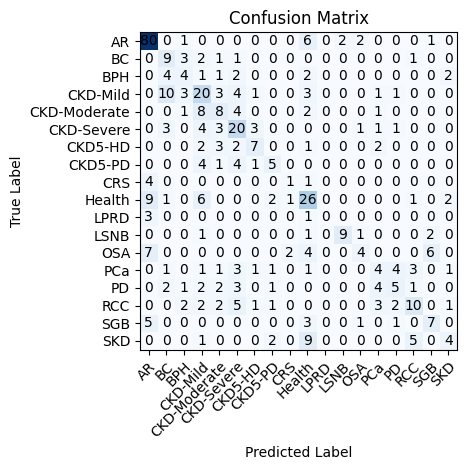

In [66]:
cm = confusion_matrix(y_test, y_pred)
class_names = y_classes # best_model.classes_
tick_marks = np.arange(len(class_names))

plt.figure()
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
# plt.colorbar()
plt.xticks(tick_marks, class_names, rotation=45, ha="right", rotation_mode="anchor")
plt.yticks(tick_marks, class_names)

# Values inside each cell
for i in range(cm.shape[0]):
	for j in range(cm.shape[1]):
		plt.text(
			j, i,
			format(cm[i, j], "d"),
			ha="center",
			va="center"
		)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [67]:
# Get node embeddings
print(z.shape)
z

torch.Size([2333, 128])


tensor([[  6.4842,  -3.7882,  -0.6854,  ...,  -5.2931,  -5.7874,   1.8469],
        [  2.4775,  -1.8293,   0.4163,  ...,  -3.7053,  -5.1409,   2.3363],
        [  0.1390,  -0.3445,  -1.1558,  ...,  -1.0435,  -3.1401,   0.8089],
        ...,
        [  1.1242,  -0.7377,  -3.2272,  ...,   3.2612, -16.5609,   7.2330],
        [  4.5204,   1.8111,  -2.0261,  ...,   1.2101,  -6.8908,   5.2257],
        [  0.8364,  -9.2884,  -3.3648,  ...,   5.4232,   9.1684,   6.0823]])

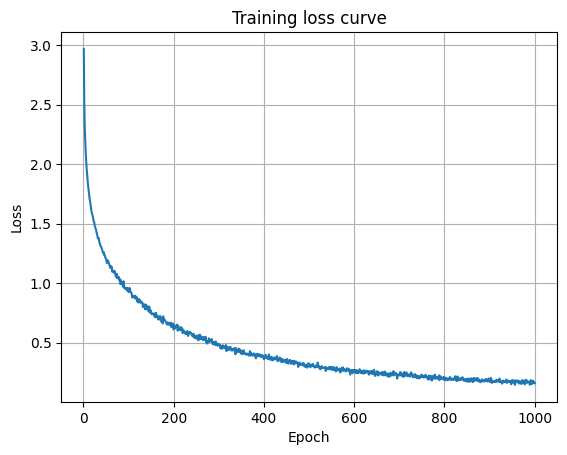

In [68]:
# Plot loss curve
plt.figure()
plt.plot(range(1, epochs + 1), losses, marker="")

# Axis labels
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Title
plt.title("Training loss curve")

# Grid for better visualization
plt.grid(True)

# Display plot
plt.show()

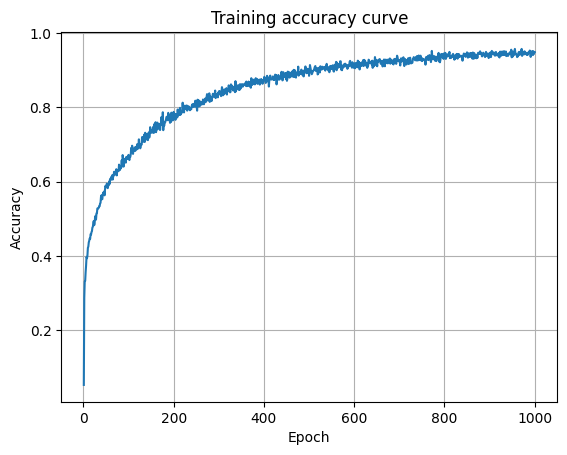

In [69]:
# Plot accuracy curve
plt.figure()
plt.plot(range(1, epochs + 1), accuracies, marker="")

# Axis labels
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

# Title
plt.title("Training accuracy curve")

# Grid for better visualization
plt.grid(True)

# Display plot
plt.show()

In [70]:
print(np.unique(data.y))
print(np.unique(y))
print(np.unique(y_original))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
['AR' 'BC' 'BPH' 'CKD-Mild' 'CKD-Moderate' 'CKD-Severe' 'CKD5-HD'
 'CKD5-PD' 'CRS' 'Health' 'LPRD' 'LSNB' 'OSA' 'PCa' 'PD' 'RCC' 'SGB' 'SKD']


In [71]:
print(len(data.y))
print(len(y))
print(len(y_original))

2333
2333
2333


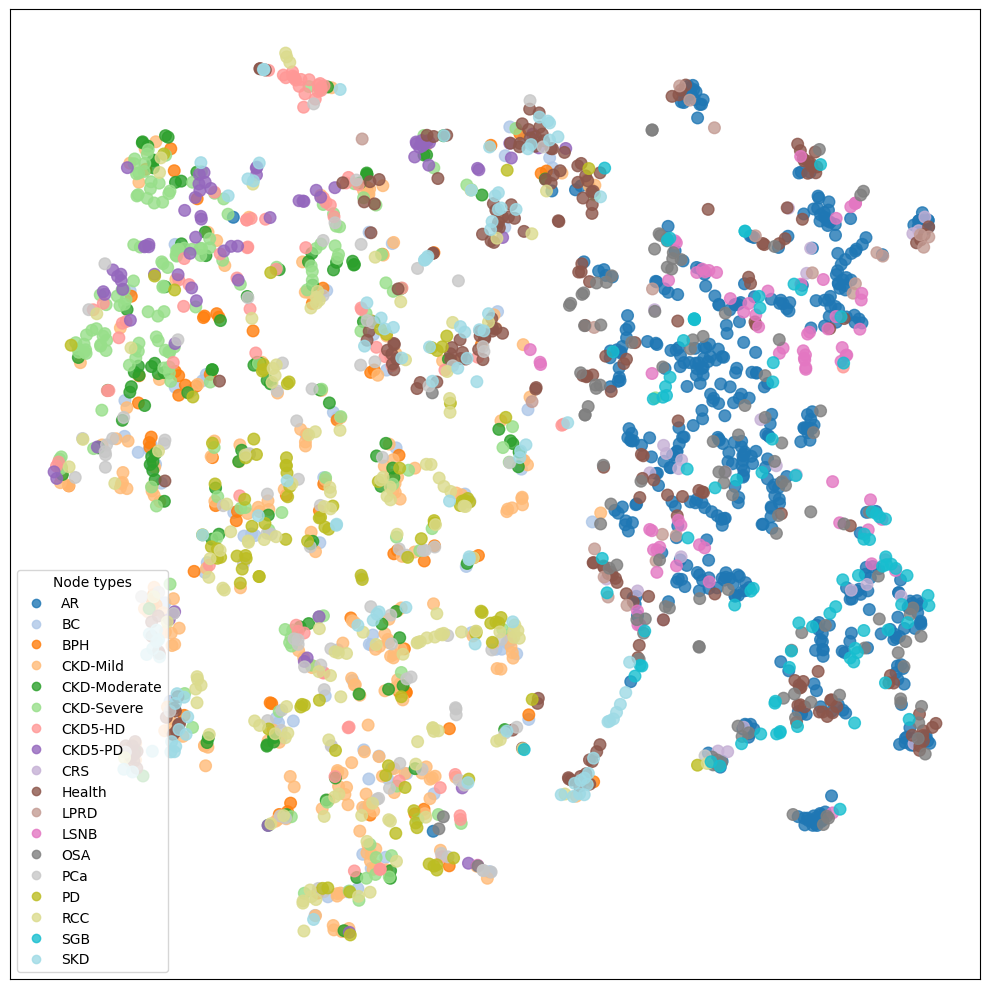

In [72]:
visualize(z, data.y, y_original)

#### GAT

In [73]:
# Define GAT
class GAT_(torch.nn.Module):
	def __init__(self, num_features, dim_h, num_classes, heads=1):
		super(GAT, self).__init__()
		torch.manual_seed(42)
		# GAT layers
		""" self.conv1 = GATv2Conv(num_features, 512, heads=heads)
		self.conv2 = GATv2Conv(512 * heads, 64, heads=heads)
		self.conv3 = GATv2Conv(64 * heads, dim_h, heads=1) """
		
		""" self.conv1 = GATv2Conv(num_features, 64, heads=4)
		self.conv2 = GATv2Conv(64 * 4, 64, heads=4)
		self.conv3 = GATv2Conv(64 * 4, dim_h, heads=1) """
		
		self.conv1 = GATv2Conv(
			num_features,
			64,
			heads=4,
			dropout=0.6
		)

		self.conv2 = GATv2Conv(
			64 * 4,
			dim_h,
			heads=1,
			concat=False,
			dropout=0.6
		)
		
		# Prediction head
		self.classifier = Linear(dim_h, num_classes)

	def forward(self, x, edge_index):
		# Node embeddings
		""" h = self.conv1(x, edge_index)
		h = h.relu()
		h = self.conv2(h, edge_index)
		h = h.relu()
		h = F.dropout(h, p=0.5, training=self.training)
		h = self.conv3(h, edge_index)
		z = h.relu()  # final GNN embedding space """
		
		""" h = self.conv1(x, edge_index)
		h = F.elu(h)
		h = F.dropout(h, p=0.5, training=self.training)
		h = self.conv2(h, edge_index)
		h = F.elu(h)
		h = F.dropout(h, p=0.5, training=self.training)
		z = self.conv3(h, edge_index) """
		
		""" x = F.dropout(x, 0.6, training=self.training)
		x = self.conv1(x, edge_index)
		x = F.elu(x)
		x = F.dropout(x, 0.6, training=self.training)
		z = self.conv2(x, edge_index) """
		
		h = self.conv1(x, edge_index)
		h = F.elu(h)
		h = F.dropout(h, p=0.6, training=self.training)
		h = self.conv2(h, edge_index)
		z = F.elu(h)
		
		# Prediction head: linear classifier
		out = self.classifier(z)
		return out, z

class GAT(torch.nn.Module):
	"""
	GAT mejorada para clasificación de nodos.
 
	Cambios respecto a la versión original:
	  1. FIX: el parámetro `heads` del constructor ahora se usa de verdad en
		 conv1 (antes estaba hardcodeado a 4, `heads` era un parámetro muerto).
	  2. Dropout en las features de entrada -- el paper original de GAT
		 (Velickovic et al. 2018) lo aplica; regulariza contra depender
		 demasiado de features de entrada específicas.
	  3. edge_dim=1 en conv1: permite pasar `edge_attr` (ej. la correlación
		 parcial de cada arista) para que la atención se calcule usando tanto
		 la estructura del grafo COMO el peso real de cada conexión, en vez de
		 aprender la importancia de cada vecino solo desde cero.
	  4. `z` se retorna SIN la activación final aplicada (mismo criterio que
		 en el GCN) -- conserva el embedding completo para reuso posterior;
		 la no-linealidad se aplica solo al alimentar el classifier.
 
	Nota: GATv2Conv ya resuelve el problema de "atención estática" de GATv1
	(Brody et al. 2022), así que usarlo en vez de GATConv ya es la elección
	correcta -- no hace falta cambiarlo.
	"""
 
	def __init__(self, num_features, dim_h, num_classes, heads=1, p_dropout=0.2):
		super().__init__()
		torch.manual_seed(42)
 
		self.dropout_in = Dropout(p_dropout)
 
		self.conv1 = GATv2Conv(
			num_features, 1024,
			heads=heads,              # <- fix: ahora sí usa el parámetro del constructor
			dropout=p_dropout,
			edge_dim=1,                # <- permite incorporar pesos de arista (opcional en forward)
		)
		self.conv2 = GATv2Conv(
			1024 * heads, dim_h,
			heads=1, concat=False,     # una sola cabeza de salida, sin concatenar
			dropout=p_dropout,
			edge_dim=1,
		)
 
		self.classifier = Linear(dim_h, num_classes)
 
	def forward(self, x, edge_index, edge_attr=None):
		x = self.dropout_in(x)
 
		h = self.conv1(x, edge_index, edge_attr=edge_attr)
		h = F.elu(h)
		h = F.dropout(h, p=0.6, training=self.training)
 
		h = self.conv2(h, edge_index, edge_attr=edge_attr)
		z = h                                  # <- embedding SIN activación (reusable)
 
		out = self.classifier(F.elu(z))         # la no-linealidad va aquí, no en z
		return out, z

# Hyperparameters
dimension = 128 # node embedding dimension d'
num_features = num_features # input feature dimension d
num_classes = num_classes # number of output classes |Y|
num_heads = 2 # number of attention heads K

# Model instantiation
model = GAT(
	num_features = num_features,
	dim_h        = dimension,
	num_classes  = num_classes,
	heads        = num_heads
)
print(model)

GAT(
  (dropout_in): Dropout(p=0.2, inplace=False)
  (conv1): GATv2Conv(159, 1024, heads=2)
  (conv2): GATv2Conv(2048, 128, heads=1)
  (classifier): Linear(in_features=128, out_features=18, bias=True)
)


In [ ]:
# Vizualization
model.eval()
out, z = model(data.x, data.edge_index)

visualize(z, data.y, y_original)

In [ ]:
# Train

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001) #, weight_decay=5e-4)#, weight_decay=5e-4)

# Data for animations
embeddings = []
losses = []
accuracies = []
outputs = []
epochs = 1000

# Training loop
pbar = tqdm(range(1, epochs + 1))
for epoch in pbar:
	# Mode train
	model.train()

	# Clear gradients
	optimizer.zero_grad()

	# Forward pass
	out, z = model(data.x, data.edge_index)

	# Calculate loss function
	loss = criterion(out[data.train_mask], data.y[data.train_mask])

	# Calculate accuracy
	acc = accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])

	# Compute gradients
	loss.backward()

	# Tune parameters
	optimizer.step()

	# Store data for animations
	embeddings.append(z)
	losses.append(loss.item())
	accuracies.append(acc)
	outputs.append(z.argmax(dim=1))

	# Print metrics
	pbar.set_description(f"Epoch {epoch:>3} | Loss: {loss:.2f} | Acc: {acc*100:.2f}%")

	# Print metrics every 10 epochs
	""" if epoch % 10 == 0:
		print(f"Epoch {epoch:>3} | Loss: {loss:.2f} | Acc: {acc*100:.2f}%") """

In [ ]:
# Evaluation
model.eval()
with torch.no_grad():
	# 2. Obtener las predicciones del modelo (log_softmax o logits)
	out, z = model(data.x, data.edge_index)
	
	# 3. Convertir las salidas en las clases predichas (índice con mayor valor)
	y_pred = out.argmax(dim=1)

# 4. Filtrar solo los nodos del conjunto de prueba (Test Set)
# Usamos .cpu().numpy() porque scikit-learn trabaja con vectores de NumPy
y_test = data.y[data.test_mask].cpu().numpy()
y_pred = y_pred[data.test_mask].cpu().numpy()

accuracy_ = accuracy_score(y_test, y_pred)
recall_macro = recall_score(y_test, y_pred, average="macro")
f1_macro = f1_score(y_test, y_pred, average="macro")
classification_rep = classification_report(y_test, y_pred, output_dict=False)

print("Accuracy: ", accuracy_)
print("Recall: ", recall_macro)
print("F1-score: ", f1_macro)

print(classification_rep)

In [ ]:
cm = confusion_matrix(y_test, y_pred)
class_names = y_classes # best_model.classes_
tick_marks = np.arange(len(class_names))

plt.figure()
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
# plt.colorbar()
plt.xticks(tick_marks, class_names, rotation=45, ha="right", rotation_mode="anchor")
plt.yticks(tick_marks, class_names)

# Values inside each cell
for i in range(cm.shape[0]):
	for j in range(cm.shape[1]):
		plt.text(
			j, i,
			format(cm[i, j], "d"),
			ha="center",
			va="center"
		)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [ ]:
# Get node embeddings
print(z.shape)
z

In [ ]:
# Plot loss curve
plt.figure()
plt.plot(range(1, epochs + 1), losses, marker="")

# Axis labels
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Title
plt.title("Training loss curve")

# Grid for better visualization
plt.grid(True)

# Display plot
plt.show()

In [ ]:
# Plot accuracy curve
plt.figure()
plt.plot(range(1, epochs + 1), accuracies, marker="")

# Axis labels
plt.xlabel("Epoch")
plt.ylabel("Train")

# Title
plt.title("Training accuracy curve")

# Grid for better visualization
plt.grid(True)

# Display plot
plt.show()

In [ ]:
visualize(z, data.y, y_original)

In [ ]:
break

### Unsupervised

In [ ]:
import argparse
import os.path as osp
import time

import torch

import torch_geometric.transforms as T
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GAE, VGAE, GCNConv


In [ ]:
data

In [ ]:
transform = T.Compose([
    # T.NormalizeFeatures(),
    # T.ToDevice(device),
    T.RandomLinkSplit(num_val=0.05, num_test=0.1, is_undirected=True,
                    split_labels=True, add_negative_train_samples=False),
])

train_data, val_data, test_data = transform(data)
train_data

In [ ]:
val_data

In [ ]:
test_data

In [ ]:
class GCNEncoder(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, 4 * out_channels)
        self.conv2 = GCNConv(4 * out_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        return self.conv2(x, edge_index)


class VariationalGCNEncoder(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, 8 * out_channels)
        self.conv_mu = GCNConv(8 * out_channels, out_channels)
        self.conv_logstd = GCNConv(8 * out_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        return self.conv_mu(x, edge_index), self.conv_logstd(x, edge_index)


class LinearEncoder(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = GCNConv(in_channels, out_channels)

    def forward(self, x, edge_index):
        return self.conv(x, edge_index)


class VariationalLinearEncoder(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv_mu = GCNConv(in_channels, out_channels)
        self.conv_logstd = GCNConv(in_channels, out_channels)

    def forward(self, x, edge_index):
        return self.conv_mu(x, edge_index), self.conv_logstd(x, edge_index)


In [ ]:
in_channels, out_channels = num_features, 128

In [ ]:
model = GAE(GCNEncoder(in_channels, out_channels))
# model = GAE(LinearEncoder(in_channels, out_channels))
# model = VGAE(VariationalGCNEncoder(in_channels, out_channels))
# model = VGAE(VariationalLinearEncoder(in_channels, out_channels))
print(model)
# model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train():
    model.train()
    optimizer.zero_grad()
    z = model.encode(train_data.x, train_data.edge_index)
    loss = model.recon_loss(z, train_data.pos_edge_label_index)
    """ if args.variational:
        loss = loss + (1 / train_data.num_nodes) * model.kl_loss() """
    # loss = loss + (1 / train_data.num_nodes) * model.kl_loss()
    loss.backward()
    optimizer.step()
    return float(loss)


@torch.no_grad()
def test(data):
    model.eval()
    z = model.encode(data.x, data.edge_index)
    return model.test(z, data.pos_edge_label_index, data.neg_edge_label_index)

times = []
epochs = 500
for epoch in range(1, epochs + 1):
    start = time.time()
    loss = train()
    auc, ap = test(test_data)
    print(f'Epoch: {epoch:03d}, AUC: {auc:.4f}, AP: {ap:.4f}')
    times.append(time.time() - start)
print(f"Median time per epoch: {torch.tensor(times).median():.4f}s")

In [ ]:
# Evaluation
model.eval()
with torch.no_grad():
	model.eval()
	z = model.encode(data.x, data.edge_index)

# Get node embeddings
print(z.shape)
z

In [ ]:
visualize(z, data.y, y_original)